## 事前準備

In [1]:
import sys
PYTHONPATH = "../"
sys.path.append(PYTHONPATH)

In [2]:
import numpy as np
import pandas as pd
from tqdm import tqdm

from reversi import strategies
from environment.environment import Env, PlayerInfo
from strategy.QLearning.q_learn_strategy import QLearnTrain, QLearnHyperParam
from strategy.QLearning.q_learn_strategy import QLearnInfra
from strategy.Edax.edax_strategy import Edax

import matplotlib.pyplot as plt

import traceback

## 学習データ準備

In [3]:
"""
白で使う戦略を定義。
弱い順に並べて、弱い相手から学習させていく。

下記は、総当たり & 各ペア500戦させた戦績

                          | Total  | Win   Lose  Draw  Match
------------------------------------------------------------
Unselfish                 |  11.0% |   286  2271    43  2600
Random                    |  13.5% |   351  2214    35  2600
Greedy                    |  18.8% |   490  2067    43  2600
SlowStarter               |  19.5% |   508  2047    45  2600
Table                     |  27.3% |   709  1844    47  2600
MinMax                    |  42.7% |  1111  1402    87  2600
NegaMax                   |  48.3% |  1256  1268    76  2600
AlphaBeta                 |  54.4% |  1414  1162    24  2600
MonteCarlo                |  54.5% |  1417  1135    48  2600
Joseki                    |  61.6% |  1601   939    60  2600
FullReading               |  62.4% |  1622   944    34  2600
Iterative                 |  87.8% |  2284   314     2  2600
Edge                      |  92.3% |  2401   199     0  2600
Switch                    |  95.3% |  2478   122     0  2600
------------------------------------------------------------
"""

# NOTE: Iterative, Edge, Switchは処理に時間かかるため対戦相手からはのぞいた
#WHITE_STRATEGY_LIST = ["Unselfish", "Random", "Greedy", "SlowStarter", "Table",
#                       "MinMax", "NegaMax", "AlphaBeta", "MonteCarlo", "Joseki",
#                       "FullReading", "Iterative", "Edge", "Switch"]
WHITE_STRATEGY_LIST = ["Unselfish", "Random", "Greedy", "SlowStarter", "Table",
                       "MinMax", "NegaMax", "AlphaBeta", "MonteCarlo", "Joseki",
                       "FullReading"]

N_WHITE_STRATEGY = len(WHITE_STRATEGY_LIST)

In [4]:
# max_episode × 白の戦略(WHITE_STRATEGY_LIST) の数だけ試合を行う 
max_episode = 10000

qlearn_param = QLearnHyperParam(
    epsilon=0.5,
    gamma=0.9,
    alpha=0.3
)

write_q_table_file_path = f"q-table/black_{qlearn_param}_vs_multi(n={N_WHITE_STRATEGY})_episode-{max_episode}x{N_WHITE_STRATEGY}.pickle"

read_q_table_file_path = None


print(f"read: {read_q_table_file_path}")
print(f"write: {write_q_table_file_path}")

read: None
write: q-table/black_e[0.5]_g[0.9]_a[0.3]_vs_multi(n=13)_episode-10000x13.pickle


## エージェント準備

In [5]:
def create_strategy(strategy_name):
    strategy = None
    if strategy_name == "Unselfish":        strategy = strategies.Unselfish()
    elif strategy_name == "Random":         strategy = strategies.Random()
    elif strategy_name == "Greedy":         strategy = strategies.Greedy()
    elif strategy_name == "SlowStarter":    strategy = strategies.SlowStarter()
    elif strategy_name == "Table":          strategy = strategies.Table()
    elif strategy_name == "MonteCarlo":     strategy = strategies.MonteCarlo1000()
    elif strategy_name == "MinMax":         strategy = strategies.MinMax2_TPW()
    elif strategy_name == "NegaMax":        strategy = strategies.NegaMax3_TPW()
    elif strategy_name == "AlphaBeta":      strategy = strategies.AlphaBeta4_TPW()
    elif strategy_name == "Joseki":         strategy = strategies.AlphaBeta4J_TPW()
    elif strategy_name == "FullReading":    strategy = strategies.AlphaBeta4F9J_TPW()
    elif strategy_name == "Iterative":      strategy = strategies.AbIF9J_B_TPW()
    elif strategy_name == "Edge":           strategy = strategies.AbIF9J_B_TPWE()
    elif strategy_name == "Switch":         strategy = strategies.SwitchNsIF10J_B_TPWE()
    else: raise ValueError(f"<{strategy_name}> という戦略は存在しません")
    return strategy

def create_player(strategy_name):
    return PlayerInfo(
        strategy_name,
        create_strategy(strategy_name)
    )

In [6]:
train_phase_black_player = {
    "q-learn": PlayerInfo(
        "q-learn",
        QLearnTrain(
            write_q_table_file_path,
            read_q_table_file_path,
            qlearn_param)
    ),
}

In [7]:
train_phase_white_player = {name: create_player(name) for name in WHITE_STRATEGY_LIST}

## 学習

In [ ]:
env = Env()

result_history_dict = {}

try:
    for idx, white_strategy_name in enumerate(WHITE_STRATEGY_LIST):
        print(f"[train vs. {white_strategy_name}] progress - {idx + 1}/{N_WHITE_STRATEGY}")
        result_history = env.simulate(max_episode, train_phase_black_player["q-learn"], train_phase_white_player[white_strategy_name])
        result_history_dict[white_strategy_name] = result_history

    train_phase_black_player["q-learn"].strategy.save_q_table()

except:
    # Out of Memoryとかで落ちてもテーブルは保存されるように対処
    traceback.print_exc()
    train_phase_black_player["q-learn"].strategy.save_q_table()

[train vs. Unselfish] progress - 1/13


100%|██████████| 10000/10000 [00:20<00:00, 498.68it/s]


[train vs. Random] progress - 2/13


100%|██████████| 10000/10000 [00:16<00:00, 590.38it/s]


[train vs. Greedy] progress - 3/13


...

100%|██████████| 10000/10000 [07:12<00:00, 23.10it/s]


[train vs. FullReading] progress - 11/13


100%|██████████| 10000/10000 [07:54<00:00, 21.09it/s]


[train vs. Edge] progress - 12/13


  2%|▏         | 189/10000 [1:16:43<66:23:01, 24.36s/it]
Traceback (most recent call last):
  File "C:\Users\tomonori\AppData\Local\Temp\ipykernel_7868\1521824500.py", line 8, in <module>
    result_history = env.simulate(max_episode, train_phase_black_player["q-learn"], train_phase_white_player[white_strategy_name])
                     ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\Dropbox\develop\working\reversi-reinforcement-learning\experiment\..\environment\environment.py", line 26, in simulate
    result = self._game.play(black_player, white_player, episode)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\Dropbox\develop\working\reversi-reinforcement-learning\experiment\..\environment\game.py", line 62, in play
    self._move(board, player, opps_player, episode)
  File "e:\Dropbox\develop\working\reversi-reinforcement-learning\experiment\..\environment\game.py", line 33, in _mo

## 学習結果確認

### 勝率

In [9]:
def print_win_rate(result_history):
    total_num = {"black": 0, "white": 0, "draw": 0}
    total_avg = {"black": 0, "white": 0, "draw": 0}
    for x in result_history:
        total_num[x["winner"]] += 1
    for k in total_num.keys():
        total_avg[k] = total_num[k] / len(result_history) * 100

    print(f"win num: {total_num}")
    print(f"win avg: {total_avg}")

In [ ]:
for idx, white_strategy_name in enumerate(WHITE_STRATEGY_LIST):
    print(f"[{idx + 1}] {white_strategy_name}")
    print_win_rate(result_history_dict[white_strategy_name])
    print()

[1] Unselfish


KeyError: 'Unselfish'

### 勝率描画

In [19]:
def plot_rolling_average(datas, interval=50, title=None, figsize=(6.4, 4.8)):
    avg = {}
    for e in range(0, len(datas), interval):
        avg[e] = np.mean(datas[e : e + interval])
    
    plt.figure(figsize=figsize) 
    pd.Series(avg).plot()
    plt.grid(True)
    if title: plt.title(title)
    plt.show()

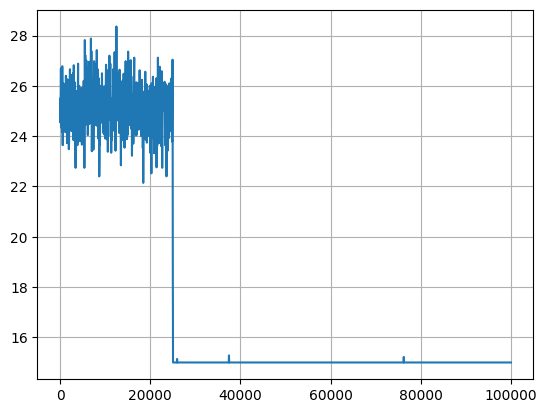

In [ ]:
for white_strategy_name in WHITE_STRATEGY_LIST:
    result_history = result_history_dict[white_strategy_name]
    title = f"vs-{white_strategy_name} n-black win"
    figsize = (6,3)

    plot_rolling_average([x["n_black"] for x in result_history], title=title, figsize=figsize)

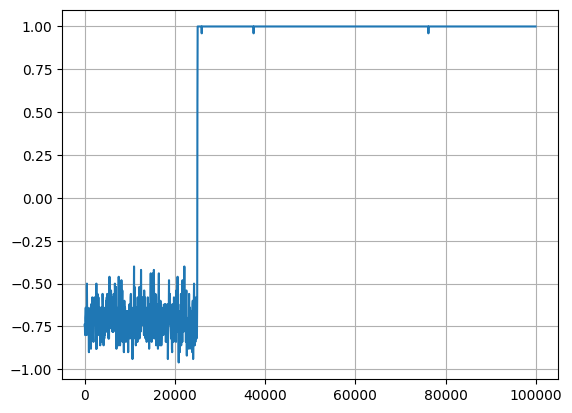

In [ ]:
def reward(x):
    if x == "black":
        return 1
    elif x == "white":
        return -1
    else:
        return 0

for white_strategy_name in WHITE_STRATEGY_LIST:
    result_history = result_history_dict[white_strategy_name]
    title = f"vs-{white_strategy_name} reward"
    figsize = (6,3)
    
    plot_rolling_average([reward(x["winner"]) for x in result_history], title=title, figsize=figsize)

### Qテーブルの確認

In [11]:
# Qテーブルの状態キー数確認
len(train_phase_black_player["q-learn"].strategy.q_table.keys())

628864

In [ ]:
# 状態キーで検索し、Q値が0以外となるものの個数を確認
# store = [(状態キー, Q値, 駒が置かれていないマス数), ...]
# 表示: (Q値が0以外となるものの状態数, Qテーブルの全状態数)
store = []
for key, value in train_phase_black_player["q-learn"].strategy.q_table.items():
    reward_sum = sum(value.values())
    
    if reward_sum > 0:
        n_blank = key[1].count("-")
        store.append((key, value, n_blank))

len(store), len(train_phase_black_player["q-learn"].strategy.q_table)

(3172, 628864)

In [13]:
store.sort(key = lambda x: x[-1], reverse=True)

In [14]:
from common.get_board_position_labels import position_to_label

def show_store_item(item):
    key, value, _ = item
    _, board = key

    for i in range(8):
        line = ""
        for j in range(8):
            idx = i * 8 + j
            line += f"{board[idx].upper()}|{value[position_to_label((j, i))]:.1f} "
        print(line)

In [15]:
# おいている駒が少なく、Q値が0以外の値がある盤面を表示
show_store_item(store[0])

-|0.0 -|0.0 -|0.0 -|0.0 -|0.0 -|0.0 -|0.0 -|0.0 
-|0.0 -|0.0 -|0.0 -|0.0 -|0.0 -|0.0 -|0.0 -|0.0 
-|0.0 -|0.0 -|0.0 -|0.0 -|0.0 -|0.0 -|0.0 -|0.0 
-|0.0 -|0.0 -|0.0 W|0.0 B|0.0 -|0.0 -|0.0 -|0.0 
-|0.0 -|0.0 -|0.0 B|0.0 W|0.0 -|0.0 -|0.0 -|0.0 
-|0.0 -|0.0 -|0.0 -|0.0 -|0.6 -|0.0 -|0.0 -|0.0 
-|0.0 -|0.0 -|0.0 -|0.0 -|0.0 -|0.0 -|0.0 -|0.0 
-|0.0 -|0.0 -|0.0 -|0.0 -|0.0 -|0.0 -|0.0 -|0.0 


## 評価
学習したエージェントとは別のものを用意して対戦させてみる

In [4]:
infra_q_table_file_path = "q-table/black_e[0.5]_g[0.9]_a[0.3]_vs_all(n=14)_episode-10000x14.pickle"


infra_phase_black_player = {
    "q-learn": PlayerInfo("q-learn", QLearnInfra(infra_q_table_file_path)),
}

infra_phase_white_player = {
    "edax": PlayerInfo("edax", Edax(None)),
}

### VS. Edax

In [5]:
env = Env()
result_history = env.simulate(10, infra_phase_black_player["q-learn"], infra_phase_white_player["edax"])

100%|██████████| 500/500 [00:00<00:00, 1519.87it/s]


In [6]:
total_num = {"black": 0, "white": 0, "draw": 0}
total_avg = {"black": 0, "white": 0, "draw": 0}
for x in result_history:
    total_num[x["winner"]] += 1
for k in total_num.keys():
    total_avg[k] = total_num[k] / len(result_history) * 100

print(f"win num: {total_num}")
print(f"win avg: {total_avg}")

win num: {'black': 500, 'white': 0, 'draw': 0}
win avg: {'black': 100.0, 'white': 0.0, 'draw': 0.0}


In [7]:
result_history

[{'winner': 'black', 'n_black': 15, 'n_white': 0},
 {'winner': 'black', 'n_black': 15, 'n_white': 0},
 {'winner': 'black', 'n_black': 15, 'n_white': 0},
 {'winner': 'black', 'n_black': 15, 'n_white': 0},
 {'winner': 'black', 'n_black': 15, 'n_white': 0},
 {'winner': 'black', 'n_black': 15, 'n_white': 0},
 {'winner': 'black', 'n_black': 15, 'n_white': 0},
 {'winner': 'black', 'n_black': 15, 'n_white': 0},
 {'winner': 'black', 'n_black': 15, 'n_white': 0},
 {'winner': 'black', 'n_black': 15, 'n_white': 0},
 {'winner': 'black', 'n_black': 15, 'n_white': 0},
 {'winner': 'black', 'n_black': 15, 'n_white': 0},
 {'winner': 'black', 'n_black': 15, 'n_white': 0},
 {'winner': 'black', 'n_black': 15, 'n_white': 0},
 {'winner': 'black', 'n_black': 15, 'n_white': 0},
 {'winner': 'black', 'n_black': 15, 'n_white': 0},
 {'winner': 'black', 'n_black': 15, 'n_white': 0},
 {'winner': 'black', 'n_black': 15, 'n_white': 0},
 {'winner': 'black', 'n_black': 15, 'n_white': 0},
 {'winner': 'black', 'n_black':

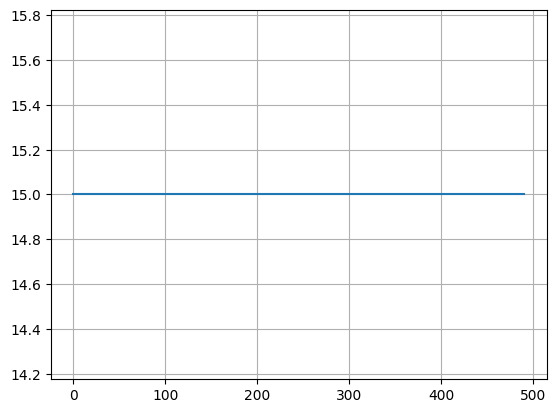

In [8]:
plot_rolling_average([x["n_black"] for x in result_history], interval=1)